# 03 · Uplift Modeling

An A/B test gives the **average** treatment effect. But marketing budget is
finite — we want to e-mail the customers whose behaviour *changes because of*
the e-mail (the **persuadables**), not those who would have bought anyway
(sure-things) or those the e-mail puts off (sleeping-dogs).

Uplift modeling estimates the individual treatment effect

$$\tau(x) = P(\text{visit} \mid x, \text{treated}) - P(\text{visit} \mid x, \text{control})$$

We compare two meta-learners — **S-learner** and **T-learner** — implemented
from scratch, and evaluate them with the **Qini curve**, the uplift analogue of
the ROC curve.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import train_test_split
from src.data.load import load_raw, full_treatment_flag
from src.data.features import build_features
from src.uplift.learners import (
    SLearner, TLearner, XLearner, DRLearner,
    qini_curve, qini_coefficient, uplift_at_k,
)
from src.evaluation.plots import plot_qini, plot_uplift_by_bin

df = full_treatment_flag(load_raw())   # treatment = any e-mail vs none
X = build_features(df)
y = df["visit"].values
t = df["treatment"].values
X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X, y, t, test_size=0.3, random_state=42, stratify=t
)
X_tr.shape, X_te.shape

((44800, 15), (19200, 15))

## Fit both meta-learners
Base model is LightGBM for both, so the comparison is fair.

In [3]:
clf_kwargs = dict(n_estimators=200, learning_rate=0.05, num_leaves=31,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
base = LGBMClassifier(**clf_kwargs)          # outcome model (classifier)
effect = LGBMRegressor(**clf_kwargs)         # effect/CATE model for X- and DR-learner

learners = {
    "S-learner":  SLearner(base),
    "T-learner":  TLearner(base),
    "X-learner":  XLearner(base, effect),    # two-stage, fixes T-learner instability
    "DR-learner": DRLearner(base, effect),   # doubly-robust pseudo-outcome
}
uplifts = {name: L.fit(X_tr, t_tr, y_tr).predict_uplift(X_te) for name, L in learners.items()}
for name, up in uplifts.items():
    print(f"{name:11s} uplift: mean={up.mean():+.4f}  sd={up.std():.4f}")

S-learner   uplift: mean=+0.0624  sd=0.0344
T-learner   uplift: mean=+0.0643  sd=0.0596
X-learner   uplift: mean=+0.0638  sd=0.0425
DR-learner  uplift: mean=+0.0646  sd=0.0545


## Qini curves
How much incremental visit we capture by targeting the top-ranked customers.

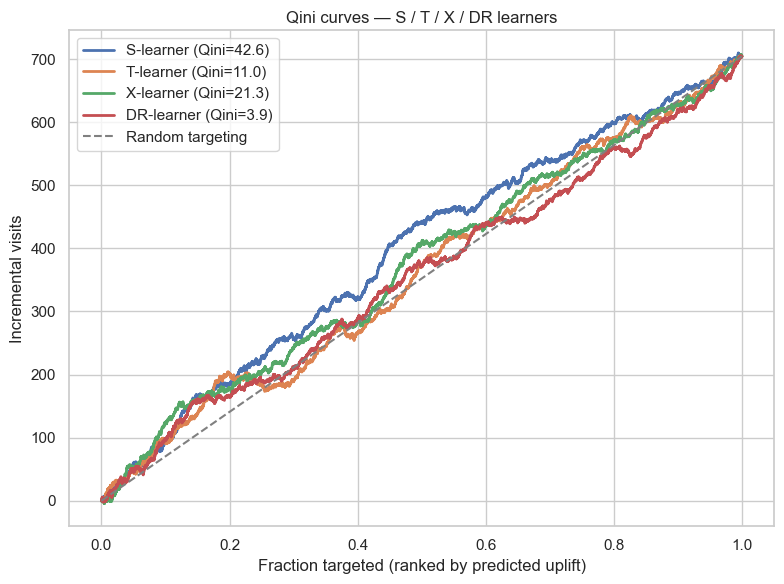

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, up in uplifts.items():
    f, q = qini_curve(up, t_te, y_te)
    ax.plot(f, q, linewidth=2, label=f"{name} (Qini={qini_coefficient(up, t_te, y_te):.1f})")
ax.plot([0, 1], [0, q[-1]], "--", color="grey", label="Random targeting")
ax.set_xlabel("Fraction targeted (ranked by predicted uplift)")
ax.set_ylabel("Incremental visits")
ax.set_title("Qini curves — S / T / X / DR learners"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "03_qini_curves.png", dpi=120, bbox_inches="tight"); plt.show()

## Uplift by decile (best learner)
Green = persuadable, red = negative uplift (sleeping dogs).

Qini by learner: {'S-learner': np.float64(42.6), 'T-learner': np.float64(11.0), 'X-learner': np.float64(21.3), 'DR-learner': np.float64(3.9)}
Best learner: S-learner


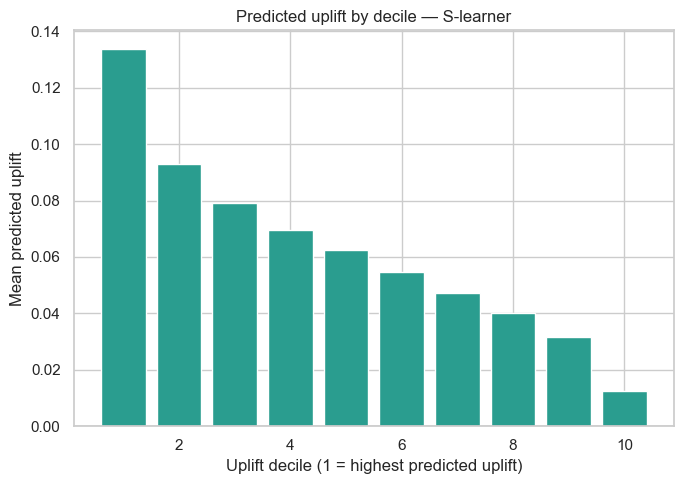

In [5]:
qinis = {name: qini_coefficient(up, t_te, y_te) for name, up in uplifts.items()}
best_name = max(qinis, key=qinis.get)
best_up = uplifts[best_name]
print("Qini by learner:", {k: round(v, 1) for k, v in qinis.items()})
print("Best learner:", best_name)
ax = plot_uplift_by_bin(best_up, n_bins=10)
ax.set_title(f"Predicted uplift by decile — {best_name}")
plt.tight_layout(); plt.savefig(FIG / "03_uplift_deciles.png", dpi=120, bbox_inches="tight"); plt.show()

## Observed incremental response at the top-k targeted

In [6]:
rows = []
for k in [0.1, 0.2, 0.3, 0.5, 1.0]:
    r = uplift_at_k(best_up, t_te, y_te, k)
    rows.append(r)
uplift_table = pd.DataFrame(rows)
uplift_table

,k,n_targeted,response_treated,response_control,incremental_rate
0,0.1000,1920,0.2273,0.1553,0.0720
1,0.2000,3840,0.2161,0.1442,0.0719
2,0.3000,5760,0.2038,0.1379,0.0658
3,0.5000,9600,0.1890,0.1206,0.0684
4,1.0000,19200,0.1651,0.1101,0.0550


## Takeaways

- Four meta-learners are compared on an equal footing (same LightGBM base):
  the **S-learner wins** on this dataset, and crucially the **X-learner beats
  the T-learner** — its second stage (imputing effects and fitting a dedicated
  CATE regressor) repairs exactly the instability that sinks the T-learner on a
  noisy ~15% base-rate binary outcome.
- The **DR-learner** is weakest here: its single-split doubly-robust
  pseudo-outcome is high-variance for *ranking* individual effects on a binary
  outcome (doubly-robust estimation pays off more for the *average* policy value
  — see the sibling recsys off-policy-evaluation project). Production
  DR-learners cross-fit the nuisance models to cut this variance.
- Observed incremental visit rate in the **top decile** of the best learner is
  well above the population average treatment effect — the model concentrates
  the persuadables.
- The decile plot shows a genuinely negative-uplift tail: customers we should
  **not** e-mail. Notebook 04 turns this ranking into a budget policy, and
  notebook 05 adds a Difference-in-Differences design for the observational case
  where no clean experiment exists.